In [2]:
# Read this
# LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_dat.csv', index=False)
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Import this: '/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_dat.csv'
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_dat.csv')
LEE_dat


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1366.529785,1366.529785,0.0,1366.529785,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1358.791834,1358.791834,0.0,1358.791834,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1403.613449,1403.613449,0.0,1403.613449,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1391.670797,1391.670797,0.0,1391.670797,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1394.996621,1394.996621,0.0,1394.996621,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18428,2024-01-27,2024-01-27,2024-01-27,3311,3311,3311,1,1343.163035,1343.163035,0.0,1343.163035,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,27
18429,2024-10-24,2024-10-24,2024-10-24,3581,3581,3581,1,1334.281033,1334.281033,0.0,1334.281033,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,297
18430,2024-11-16,2024-11-16,2024-11-16,3604,3604,3604,1,1362.699375,1362.699375,0.0,1362.699375,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,320
18431,2024-12-20,2024-12-20,2024-12-20,3638,3638,3638,1,1360.416107,1360.416107,0.0,1360.416107,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,354


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/seaborn/distributions.py:267: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  baselines[cols] = curves[cols].shift(1, axis=1).fillna(0)
/tmp/ipykernel_197201/1855532183.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='ESM Run')
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


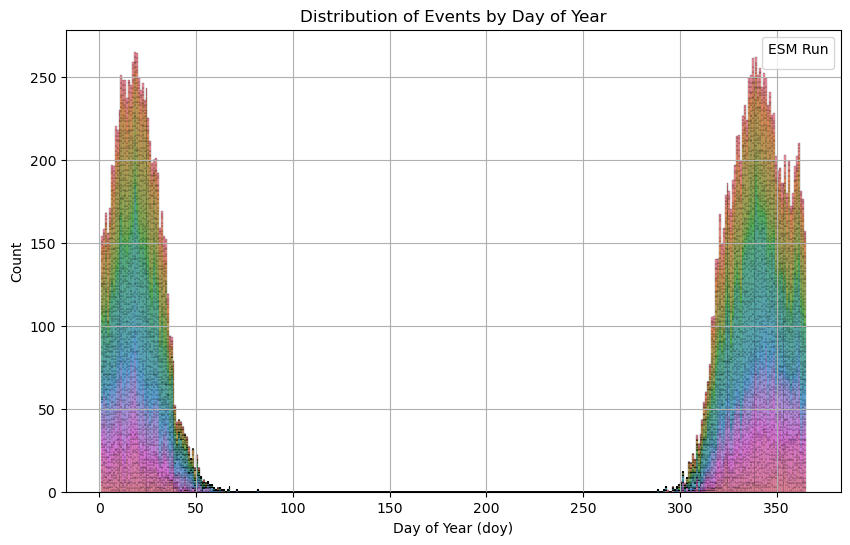

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=LEE_dat, x='doy', hue='ESM_run',
             multiple='stack', bins=365, kde=False, stat='count')
plt.xlabel('Day of Year (doy)')
plt.ylabel('Count')
plt.title('Distribution of Events by Day of Year')
plt.legend(title='ESM Run')
plt.grid(True)
plt.show()

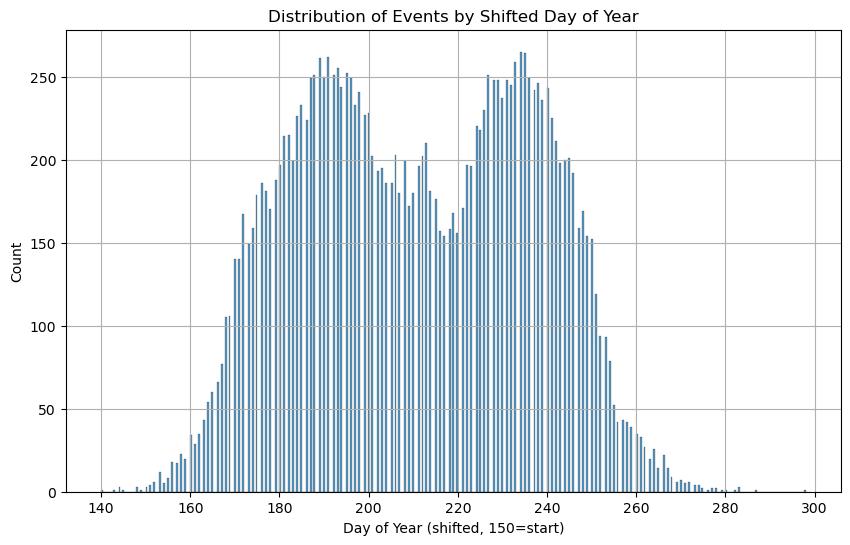

In [8]:
# Group by doy and plot against doy as histogram
# Shift 'doy' so that day 150 is at the start, wrapping days before 150 to the end
shift_point = 150
LEE_dat['doy_shifted'] = ((LEE_dat['doy'] - shift_point) % 365) + 1

plt.figure(figsize=(10, 6))
sns.histplot(data=LEE_dat, x='doy_shifted',
             multiple='stack', bins=365, kde=False, stat='count')
plt.xlabel('Day of Year (shifted, 150=start)')
plt.ylabel('Count')
plt.title('Distribution of Events by Shifted Day of Year')
plt.grid(True)
plt.show()

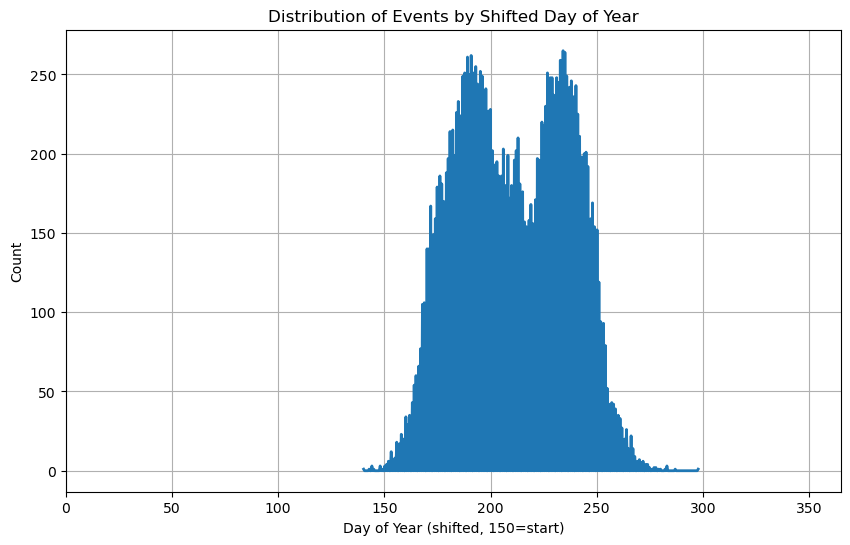

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# shift the DOY column
shift_point = 150
LEE_dat['doy_shifted'] = ((LEE_dat['doy'] - shift_point) % 365) + 1

# 1) histogram counts + edges
counts, edges = np.histogram(LEE_dat['doy_shifted'], bins=365, density=False)

# 2) compute bin-centers for a continuous x-axis
centers = (edges[:-1] + edges[1:]) / 2

# 3) plot as a line
plt.figure(figsize=(10, 6))
plt.plot(centers, counts, lw=2)
plt.fill_between(centers, counts, alpha=0.3)  # optional shading
plt.xlabel('Day of Year (shifted, 150=start)')
plt.ylabel('Count')
plt.title('Distribution of Events by Shifted Day of Year')
plt.xlim(0, 365)
plt.grid(True)
plt.show()
